In [1]:
# 1. Imports for data manipulation, visualization and modeling
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

In [10]:
# Load dataset from Liiga API
url = "https://liiga.fi/api/v2/games?season=2025"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(req) as response:
    data = json.loads(response.read().decode())

df = pd.json_normalize(data)
cols = [
    "id", "homeTeam.teamName", "awayTeam.teamName",
    "homeTeam.goals", "awayTeam.goals",
    "homeTeam.expectedGoals", "awayTeam.expectedGoals",
    "spectators"
]
df_liiga = df[cols].copy()
df_liiga.columns = [
    "id", "home_team", "away_team",
    "home_goals", "away_goals",
    "home_xg", "away_xg",
    "spectators"
]

# Check shape and missing values
print("Dataset shape:", df_liiga.shape)
print("\nMissing values before cleaning:")
print(df_liiga.isna().sum())

# Drop missing values
df_clean = df_liiga.dropna(subset=["home_xg", "away_xg", "spectators"]).copy()
print("\nDataset shape after cleaning:", df_clean.shape)

Dataset shape: (614, 8)

Missing values before cleaning:
id             0
home_team      0
away_team      0
home_goals     0
away_goals     0
home_xg       32
away_xg       32
spectators     0
dtype: int64

Dataset shape after cleaning: (582, 8)


In [11]:
# Create target variable (1 = Home Win, 0 = Non-Home Win)
df_clean["home_win"] = (df_clean["home_goals"] > df_clean["away_goals"]).astype(int)

# Create expected goals difference feature
df_clean["xg_diff"] = df_clean["home_xg"] - df_clean["away_xg"]

# Check class balance of the target variable
print("Class balance (home_win):")
print(df_clean["home_win"].value_counts(normalize=True))

Class balance (home_win):
home_win
1    0.539519
0    0.460481
Name: proportion, dtype: float64


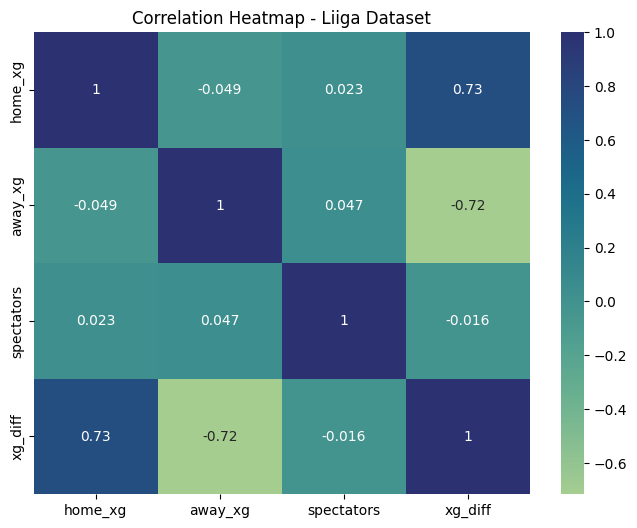

In [12]:
# Correlation Matrix to check model assumptions (no severe multicollinearity)
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[["home_xg", "away_xg", "spectators", "xg_diff"]].corr(), annot=True, cmap="crest")
plt.title("Correlation Heatmap - Liiga Dataset")
plt.show()

In [13]:
# Select features (X) and target variable (y)
X = df_clean[["home_xg", "away_xg", "spectators"]]
y = df_clean["home_win"]

# Split data into training and testing sets (75% train / 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (436, 3), X_test shape: (146, 3)


In [14]:
# Instantiate and fit Logistic Regression model
log_clf = LogisticRegression(random_state=42, max_iter=1000)
log_clf.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


--- Classification Report ---
              precision    recall  f1-score   support

Non-Home Win       0.53      0.37      0.44        67
    Home Win       0.58      0.72      0.64        79

    accuracy                           0.56       146
   macro avg       0.55      0.55      0.54       146
weighted avg       0.56      0.56      0.55       146

ROC-AUC Score: 0.5866


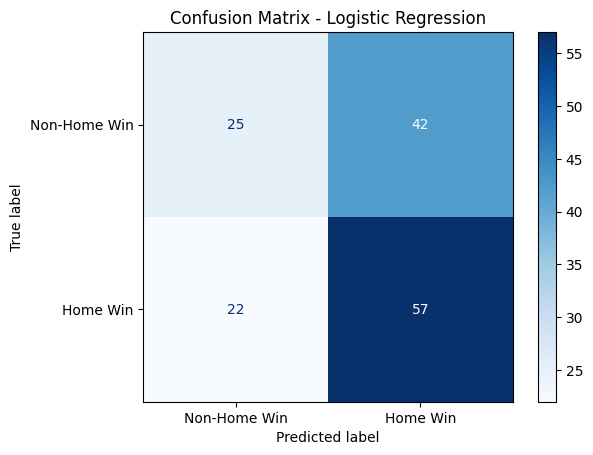

In [15]:
# Predict on test set
y_pred = log_clf.predict(X_test)
y_pred_proba = log_clf.predict_proba(X_test)[:, 1]

# Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Non-Home Win", "Home Win"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Home Win", "Home Win"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [16]:
# Extract coefficients and compute Odds Ratios (exp(beta))
coefficients = pd.DataFrame({
    "Feature Name": log_clf.feature_names_in_,
    "Log-Odds Coefficient (beta)": log_clf.coef_[0],
    "Odds Ratio (exp(beta))": np.exp(log_clf.coef_[0])
})

coefficients

,Feature Name,Log-Odds Coefficient (beta),Odds Ratio (exp(beta))
0,home_xg,0.312652,1.367046
1,away_xg,-0.469749,0.625159
2,spectators,0.000035,1.000035
